In [227]:
from langchain_core.tools import tool
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders  import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,START,END
from typing import Annotated,TypedDict
from langchain_core.messages import HumanMessage,BaseMessage
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langgraph.graph import add_messages

In [228]:
from pathlib import Path
from dotenv import load_dotenv
import os

load_dotenv(Path(r"D:\AI\BRAND_BRIDGE") / ".env", override=True)
google_api_key = os.getenv("GOOGLE_API_KEY")
database_url = os.getenv("DATABASE_URL")
print("GOOGLE_API_KEY loaded:", bool(google_api_key))
print("DATABASE_URL loaded:", bool(database_url))

GOOGLE_API_KEY loaded: True
DATABASE_URL loaded: True


In [229]:
llm=ChatGoogleGenerativeAI(model="gemini-3.8-flash",google_api_key=google_api_key)

In [230]:
loader=PyPDFLoader("Vivo_Smartphone_Influencer_Brief_Final.pdf")
docs=loader.load()

In [231]:
len(docs)

3

In [232]:
splitter=RecursiveCharacterTextSplitter(chunk_size=200,chunk_overlap=50)
chunks=splitter.split_documents(docs)
len(chunks)


51

In [233]:
embeddings=GoogleGenerativeAIEmbeddings(model="gemini-embedding-2")


In [234]:
from langchain_postgres import PGVector
from sqlalchemy import create_engine, text

database_url = os.getenv("DATABASE_URL")
if not database_url:
    raise ValueError(
        "DATABASE_URL is empty. Re-run the load_dotenv cell after saving .env."
    )

engine = create_engine(database_url)
with engine.connect() as conn:
    conn.execute(text("CREATE EXTENSION IF NOT EXISTS vector"))
    conn.commit()

print("Connected to PostgreSQL and enabled pgvector.")

Connected to PostgreSQL and enabled pgvector.


In [235]:
vector_store = PGVector(
    embeddings=embeddings,
    collection_name="Vivo_Smartphone_Influencer_Brief_Final",
    connection=database_url,
    use_jsonb=True,
)

In [236]:
docs_to_index = chunks[:20]

batch_size = 20

for i in range(0, len(docs_to_index), batch_size):
    batch = docs_to_index[i:i + batch_size]

    vector_store.add_documents(batch)

    print(
        f"Indexed {min(i + batch_size, len(docs_to_index))}"
        f"/{len(docs_to_index)}"
    )

Indexed 20/20


In [237]:
results = vector_store.similarity_search(
    "What type of influencers does this campaign require?",
    k=15
)

retrieved_chunks = "\n\n".join(
    doc.page_content for doc in results
)

result = rag_tool.invoke({
    "retrieved_chunks": retrieved_chunks
})

print(result)

[{'type': 'text', 'text': '```json\n{\n  "influencer_requirements": {\n    "name": "To be selected by the influencer-matching system",\n    "contact_information": "To be provided after selection",\n    "platform": "Instagram and/or YouTube",\n    "followers": "50,000+",\n    "average_views_per_post_video": "20,000+",\n    "engagement_rate": "4%+",\n    "average_likes": "1,000+",\n    "average_comments": "50+"\n  }\n}\n```', 'extras': {'signature': 'EmcKZQERTTIPeIdIHNXHDHKnh1oW7ZWdyBIpruVxmGeAaRnqeabu6tn7pa//zO87njssLCdJT0ucBkvgwHrYnHhVQXc8as/t+HnNf4iuUKgBgbXZd2bCjTAwP2/QgLbi+ZsLvCrG0E33'}}]


In [238]:


@tool
def rag_tool(retrieved_chunks: str):
    """
    Extract campaign requirements from retrieved campaign brief chunks.
    Return the requirements in structured JSON format.
    """

    prompt = f"""
    Extract the campaign requirements from the following
    retrieved campaign brief.

    Return ONLY valid JSON.

    Do not invent information that is not present
    in the retrieved content.

    Retrieved content:
    {retrieved_chunks}
    """

    response = llm.invoke(prompt)

    return response.content

In [239]:
tools=[rag_tool]
llm_with_tool=llm.bind_tools(tools)

In [240]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [241]:
def chat_node(state:ChatState):
    messages= state['messages']
    response= llm_with_tool.invoke(messages)
    return {'messages':[response]}

In [242]:
tool_node=ToolNode(tools)

In [243]:
graph=StateGraph(ChatState)


graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')

chatbot = graph.compile()

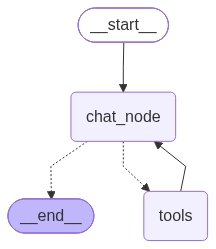

In [244]:
chatbot

In [245]:
result=chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "using the pdf given, What type of influencers does this campaign require?"
                )
            )
        ]
    }
)



In [246]:
print(result['messages'][-1].content)

[{'type': 'text', 'text': 'It appears that no PDF or campaign brief was attached or provided with your message. \n\nPlease upload the PDF or paste the campaign details here, and I will gladly analyze it to tell you what type of influencers the campaign requires!', 'extras': {'signature': 'EuMFCuAFARFNMg/zcLYmN/loe/EKIungaFZOwjOjw3Vb0chkcDjafMo81PoLxPZ6Eg/7Obx36TL8uNzI+6Dix4QNVCDSiiXypAEgY6w1smj/0Ol0V5lfq5nO+Xb6hpyYl3sIUUSMrr0oufOkJxExbphwLa1Iwqkt2GwN8OGcpymOI/c9JdGHBSXtfE/i5IceZz7PpshAKE15w8JVKiKC+P3ykGcbeGoZnmSMdZs+dALjev+2tUh6RlCCiIlxuCZv+HLCDB24y5hCTif5h1c4x+tqu0+X/M9v/J/GN/YiFnoXjTsnzJSitpPmk86NAOMT4doYoQQUEUTEuTmE9sOnCLnGEBqXj8XzkNn19WASro4l0q5l3tYe0PsEeHQ92ZjuAMDvN/XvTJCB0Z+X76QYCtacRoSKvEuSbW7UEKfKYpz/XLY0ibrjisRohDF1bIDg6lyDTLrc/1etdDQlqI5oZlwqwQe9Q9LPPYGzyRLXUV9YSdymj1t8dbkQy4vh8x1Jj+KAp3hRs9ylzeG0yF6Ff/B+cE8ltRMyjLRIzlRbZdwxnclm2EDoMLSEYktAWQNXrt3E0rwGTqbHj9On0E2pMIFr975snlvWOZHhr0GBCdekmJWGx8+0dxULk6LkjjNhZEV1h2FzsUunfMh7n3G/2UXdgyylXrBJKeJJNpACy7Mk8EXTFKgrWryBKR9CK+EfqsPbUl